In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Score Matching, Diffusion, and Flow Matching

The preceding sections built the tools: numerical solvers for ODEs
(that section), the forward noising SDE
(that section), and the central reduction that *the only unknown
standing between noise and data is the score* $\nabla \log p_t$
(that section). What remains is to *learn*
that unknown, and the method behind today's image, audio, and video generators
is simple: **learn a score or a velocity field by a plain least-squares
regression, then sample by solving the learned ODE or SDE.** We develop score
matching and its tractable denoising form, recognize DDPM
[@ho2020denoising] as a discretized variance-preserving SDE, derive
Langevin sampling, DDIM, and guidance from the same score calculus, and then
build flow matching and rectified flow as the complementary route that
*prescribes* the noise-to-data path, closing with the optimal-transport
connection between straight paths and kinetic energy and a single table that
unifies the whole family [@song2021score; @Lipman.Chen.BenHamu.ea.2022].

One idea powers everything. The quantity we want, a marginal score or a
marginal velocity, is an *average* we cannot compute. But it is the
conditional expectation of a *per-sample* quantity we can compute in closed
form, and least-squares regression against a noisy target automatically fits
its conditional mean. Every training objective in this section, implicit
score matching aside, is a restatement of this one observation.

We lean on the Fokker–Planck equation and the probability-flow ODE
(that section, that section), the
Ornstein–Uhlenbeck process (that section), Euler and
Euler–Maruyama steps (that section,
that section), and the divergences of
that section (Fisher divergence via
that section, optimal transport via
that section). The code is deliberately light: two tiny
training loops (a one-dimensional score network in plain NumPy and a
two-dimensional flow-matching model, the latter retrained once more to measure
reflow) plus closed-form simulations for everything else.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
import numpy as np
import optax

## Learning the Score

### Why the Score?

Fitting a density $p_{\boldsymbol{\theta}}$ to data by maximum likelihood
requires evaluating its normalizing constant, for a neural-network
energy-based model a $d$-dimensional integral with no closed form. The
**score** $\nabla_{\mathbf{x}} \log p_{\boldsymbol{\theta}}$ never sees that
constant (the equation; re-derived for energy-based models in
that section), so whatever we can do with scores alone,
we can do without ever normalizing. So instead of matching densities, match
score fields: take a model
$\mathbf{s}_{\boldsymbol{\theta}} : \mathbb{R}^d \to \mathbb{R}^d$ (any vector
field, e.g. a neural network; it need not be a gradient) and minimize the
Fisher divergence between model and data
(that section),

$$
J_{\mathrm{ESM}}(\boldsymbol{\theta})
= \tfrac{1}{2}\, \mathbb{E}_{\mathbf{x} \sim p}
\left[\, \left\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) - \nabla \log p(\mathbf{x}) \right\|^2 \right],
$$

called **explicit score matching**. One step forward, one step back: the
normalizer is gone, but the objective now contains $\nabla \log p$, the score
of the *data* distribution, which is exactly what we do not know. Hyvärinen's
insight is that an integration by parts removes it
[@Hyvarinen.2005].

**Proposition (Hyvärinen's identity).** *Let $p$ be a smooth positive density
and $\mathbf{s}_{\boldsymbol{\theta}}$ a smooth vector field, with
$p(\mathbf{x})\, \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) \to \mathbf{0}$
as $\|\mathbf{x}\| \to \infty$ and all the expectations below finite. Then*

$$
J_{\mathrm{ESM}}(\boldsymbol{\theta})
= \mathbb{E}_{\mathbf{x} \sim p}
\left[\, \tfrac{1}{2} \| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) \|^2
+ \nabla \cdot \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) \right] + C,
$$

*where $\nabla \cdot \mathbf{s}_{\boldsymbol{\theta}} = \sum_i \partial s_i / \partial x_i$
is the divergence and $C$ does not depend on $\boldsymbol{\theta}$.*

**Proof.** Expand the square in the equation: the term
$\tfrac12 \mathbb{E}\|\nabla \log p\|^2$ is the constant $C$, the term
$\tfrac12 \mathbb{E}\|\mathbf{s}_{\boldsymbol{\theta}}\|^2$ appears verbatim in
the equation, and the cross term is the one that needs work. In
one dimension,

$$
-\mathbb{E}_{x \sim p}\left[ s_{\boldsymbol{\theta}}(x)\, (\log p)'(x) \right]
= -\int s_{\boldsymbol{\theta}}(x)\, \frac{p'(x)}{p(x)}\, p(x)\, dx
= -\int s_{\boldsymbol{\theta}}(x)\, p'(x)\, dx,
$$

and integrating by parts with the boundary term
$\left[ s_{\boldsymbol{\theta}} \, p \right]_{-\infty}^{\infty} = 0$ leaves
$+\int s_{\boldsymbol{\theta}}'(x)\, p(x)\, dx = \mathbb{E}_p[s_{\boldsymbol{\theta}}']$.
The unknown score has disappeared into a derivative of the *model*. In $d$
dimensions, apply the same one-dimensional step to each coordinate $i$ (with
$s_i$ in place of $s_{\boldsymbol{\theta}}$ and $\partial_i p$ in place of
$p'$, integrating coordinate-wise, which Fubini justifies under the stated
integrability) and sum: the cross term becomes
$\mathbb{E}_p[\sum_i \partial_i s_i] = \mathbb{E}_p[\nabla \cdot \mathbf{s}_{\boldsymbol{\theta}}]$.
$\blacksquare$

Every quantity in the equation is an expectation under $p$ of
something we can evaluate, so we can minimize it from samples alone, with no
$Z_{\boldsymbol{\theta}}$ and no $\nabla \log p$; the right-hand side is called
**implicit score matching**. The intuition for the two terms:
the $\nabla \cdot \mathbf{s}_{\boldsymbol{\theta}}$ term rewards score fields
that point *inward* toward the data (negative divergence at the samples, like
$-\nabla E$ near a minimum), while $\tfrac12\|\mathbf{s}_{\boldsymbol{\theta}}\|^2$
stops the field from growing without bound.

Why, then, is implicit score matching not the loss behind modern diffusion
models? Cost. The divergence is the trace of the Jacobian,
$\nabla \cdot \mathbf{s}_{\boldsymbol{\theta}} = \operatorname{tr}\, (\partial \mathbf{s}_{\boldsymbol{\theta}} / \partial \mathbf{x})$,
and computing it exactly takes $d$ backward passes
(that section): the same trace bottleneck that
afflicts continuous normalizing flows
(that section), and just as there, Hutchinson
trace estimates only trade compute for variance. For images, $d$ is in the
millions. The fix is a better identity.

### Denoising Score Matching

The trick that made score models practical is to stop matching the score of the
clean data and match the score of *Gaussian-blurred* data instead
[@Vincent.2011]. Perturb each sample with Gaussian noise of scale
$\sigma$:

$$
\tilde{\mathbf{x}} = \mathbf{x} + \sigma \boldsymbol{\epsilon}, \qquad
\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, I), \qquad
\textrm{i.e.}\quad
p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) = \mathcal{N}(\tilde{\mathbf{x}};\, \mathbf{x},\, \sigma^2 I).
$$

The noised marginal $p_\sigma(\tilde{\mathbf{x}}) = \int p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})\, p(\mathbf{x})\, d\mathbf{x}$
is the data density convolved with a Gaussian: for small $\sigma$, a faithful
smoothing of $p$. Its score is still intractable. But the score of the
*conditional* is a one-line computation: taking $\log$ of the Gaussian density,

$$
\nabla_{\tilde{\mathbf{x}}} \log p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})
= \frac{\mathbf{x} - \tilde{\mathbf{x}}}{\sigma^2}
= -\frac{\boldsymbol{\epsilon}}{\sigma}.
$$

It points from the noisy point straight back to its clean origin: "undo the
noise you just added." **Denoising score matching** (DSM) regresses on that:

$$
J_{\mathrm{DSM}}(\boldsymbol{\theta})
= \mathbb{E}_{\mathbf{x} \sim p,\ \tilde{\mathbf{x}} \sim p_\sigma(\cdot \mid \mathbf{x})}
\left[\, \left\| \mathbf{s}_{\boldsymbol{\theta}}(\tilde{\mathbf{x}})
- \nabla_{\tilde{\mathbf{x}}} \log p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) \right\|^2 \right].
$$

Why on earth should regressing toward *per-sample* arrows recover the score of
the *marginal*? Because least squares always fits a conditional mean. We record
this as a lemma: it is the engine of the whole section, and we will invoke it
again, word for word, to prove the flow-matching theorem.

**Lemma (regression to the conditional mean).** *Let $(X, Y)$ be jointly
distributed with $\mathbb{E}\|Y\|^2 < \infty$ and let
$\mathbf{m}(X) = \mathbb{E}[Y \mid X]$. Then for every measurable
$\mathbf{v}$,*

$$
\mathbb{E} \left\| \mathbf{v}(X) - Y \right\|^2
= \mathbb{E} \left\| \mathbf{v}(X) - \mathbf{m}(X) \right\|^2
+ \mathbb{E} \left\| Y - \mathbf{m}(X) \right\|^2.
$$

*The second term does not involve $\mathbf{v}$: minimizing a least-squares loss
against the noisy target $Y$ is the same problem as minimizing it against the
conditional mean $\mathbf{m}(X)$, up to an additive constant.*

**Proof.** Insert $\pm\mathbf{m}(X)$ and expand. The cross term is
$2\, \mathbb{E}\left[ (\mathbf{v}(X) - \mathbf{m}(X))^\top (\mathbf{m}(X) - Y) \right]$;
conditioning on $X$ (the tower rule,
that section) and using
$\mathbb{E}[\mathbf{m}(X) - Y \mid X] = \mathbf{0}$ kills it. $\blacksquare$

**Proposition (Vincent's theorem).** *Under the conditions above, with
expectations finite,*

$$
J_{\mathrm{DSM}}(\boldsymbol{\theta})
= \mathbb{E}_{\tilde{\mathbf{x}} \sim p_\sigma}
\left[\, \left\| \mathbf{s}_{\boldsymbol{\theta}}(\tilde{\mathbf{x}}) - \nabla \log p_\sigma(\tilde{\mathbf{x}}) \right\|^2 \right] + C,
$$

*with $C$ independent of $\boldsymbol{\theta}$: denoising score matching and
explicit score matching on the noised marginal (the right-hand side is twice
the equation with $p_\sigma$ in place of $p$) have the same
minimizers and, up to that overall factor of two, the same gradients.*

**Proof.** Apply the lemma with $X = \tilde{\mathbf{x}}$ and
$Y = \nabla_{\tilde{\mathbf{x}}} \log p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})$.
It remains to identify the conditional mean, and *the marginal score is the
posterior mean of the conditional scores*:

$$
\mathbb{E}\left[ Y \mid \tilde{\mathbf{x}} \right]
= \int \frac{\nabla_{\tilde{\mathbf{x}}}\, p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})}{p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})}
\; \frac{p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})\, p(\mathbf{x})}{p_\sigma(\tilde{\mathbf{x}})}\, d\mathbf{x}
= \frac{\nabla_{\tilde{\mathbf{x}}} \int p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})\, p(\mathbf{x})\, d\mathbf{x}}{p_\sigma(\tilde{\mathbf{x}})}
= \nabla \log p_\sigma(\tilde{\mathbf{x}}),
$$

where the first equality writes out the posterior
$p(\mathbf{x} \mid \tilde{\mathbf{x}})$ by Bayes' rule and the second swaps the
gradient with the integral. $\blacksquare$

Notice what the proof did *not* use: that the kernel is Gaussian. Any smooth
noising kernel works; the Gaussian is chosen because its conditional score
the equation is linear in the noise, making the regression target
trivial. By the equation, predicting the score and predicting the
noise $\boldsymbol{\epsilon}$ are the same task up to the factor $-1/\sigma$:
the "$\boldsymbol{\epsilon}$-prediction" of diffusion models, three
sections early. Two corollaries follow.

* **Tweedie's formula** [@Efron.2011]. Rearranging
  $\mathbb{E}[(\mathbf{x} - \tilde{\mathbf{x}})/\sigma^2 \mid \tilde{\mathbf{x}}] = \nabla \log p_\sigma(\tilde{\mathbf{x}})$
  gives
  $\mathbb{E}[\mathbf{x} \mid \tilde{\mathbf{x}}] = \tilde{\mathbf{x}} + \sigma^2\, \nabla \log p_\sigma(\tilde{\mathbf{x}})$:
  *the optimal denoiser is a step up the score*
  (the figure). Score estimation and denoising
  are the same function.
* **The loss does not go to zero.** By the equation the DSM
  loss at the optimum equals
  $\mathbb{E}\|Y - \mathbf{m}(X)\|^2$, the average posterior variance
  of the conditional score: many clean points $\mathbf{x}$ explain the same
  $\tilde{\mathbf{x}}$, and no network can resolve which one produced it. A
  large, plateauing training loss is *built into the objective*; remember
  this the first time you train a diffusion model and the loss refuses
  to drop. We will see the same plateau in the flow-matching loss later.

![Tweedie's formula. A noisy observation $\tilde{x}$ sits in the low-density valley of the smoothed mixture $p_\sigma$; the exact posterior over its clean origin is bimodal but lopsided, and the single step up the score, $\tilde{x} + \sigma^2 \nabla \log p_\sigma(\tilde{x})$, lands exactly on the posterior mean $\hat{x}_0$, the optimal denoiser.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-tweedie.svg)

### A Score Network in One Dimension

Take the bimodal mixture
$p = \tfrac12 \mathcal{N}(-2, 0.5^2) + \tfrac12 \mathcal{N}(2, 0.5^2)$, noise
scale $\sigma = 0.5$, and fit a tiny multilayer perceptron
$s_{\boldsymbol{\theta}} : \mathbb{R} \to \mathbb{R}$ by minimizing
the equation: the inputs are noised samples, the regression
targets are $-\epsilon/\sigma$, and nothing about the true density enters
training. Because the noised marginal is again a Gaussian mixture (variance
$0.5^2 + \sigma^2 = 0.5$ per component), we have the analytic
$\nabla \log p_\sigma$ to grade the result against. The network is small enough
that we write its forward pass, its backward pass
(that section), and an Adam update by hand in
plain NumPy, with no framework in the loop.

DSM loss 2.036 vs irreducible floor 2.038; max |s_theta - score| on [-4, 4]: 0.199


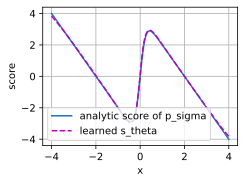

In [2]:
rng = np.random.default_rng(7)
n, sigma = 4096, 0.5
x = rng.normal(4.0 * rng.integers(0, 2, n) - 2.0, 0.5)    # x ~ p, the mixture

def mixture_score(q, var, means=(-2.0, 2.0)):             # analytic score
    w = np.stack([np.exp(-(q - m)**2 / (2 * var)) for m in means])
    return (w * np.stack([(m - q) / var for m in means])).sum(0) / w.sum(0)

# A 1 -> 32 -> 1 tanh network, with hand-written backprop and Adam updates
W1, b1 = rng.normal(size=(1, 32)), np.zeros(32)
W2, b2 = rng.normal(size=(32, 1)) / np.sqrt(32), np.zeros(1)
params = [W1, b1, W2, b2]
mom = [np.zeros_like(p) for p in params]
vel = [np.zeros_like(p) for p in params]
for step in range(2000):
    eps = rng.standard_normal(n)                          # fresh noise per step
    xt, y = (x + sigma * eps)[:, None], (-eps / sigma)[:, None]
    H = np.tanh(xt @ W1 + b1)                             # forward pass
    S = H @ W2 + b2
    G = 2 * (S - y) / n                                   # backward pass
    GH = (G @ W2.T) * (1 - H**2)
    grads = [xt.T @ GH, GH.sum(0), H.T @ G, G.sum(0)]
    for p, g, m, v in zip(params, grads, mom, vel):       # Adam updates
        m[:] = 0.9 * m + 0.1 * g
        v[:] = 0.999 * v + 0.001 * g * g
        p -= 1e-2 * m / (np.sqrt(v) + 1e-8)
loss = ((S - y)**2).mean()
floor = ((mixture_score(x + sigma * eps, 0.5) + eps / sigma)**2).mean()
grid = np.linspace(-4, 4, 201)
s_hat = (np.tanh(grid[:, None] @ W1 + b1) @ W2 + b2)[:, 0]
print(f'DSM loss {loss:.3f} vs irreducible floor {floor:.3f}; '
      f'max |s_theta - score| on [-4, 4]: {np.abs(s_hat - mixture_score(grid, 0.5)).max():.3f}')
d2l.plot(grid, [mixture_score(grid, 0.5), s_hat], 'x', 'score',
         legend=['analytic score of p_sigma', 'learned s_theta'])

The learned field tracks the analytic score across both modes and the
low-density valley between them: the largest gap on $[-4, 4]$ is about
$0.2$, on a curve whose values span $\pm 4$ (the smoothed score is
$s(x) = 4\tanh(4x) - 2x$, extremal at the interval ends). And the printout verifies the regression
lemma numerically: the final DSM loss ($\approx 2.04$) sits exactly at the
irreducible floor $\mathbb{E}\|Y - \mathbf{m}(X)\|^2$ ($\approx 2.04$,
estimated with the analytic score). The network has learned everything the
objective can teach.

## Score-Based Diffusion Models

### From One Noise Level to All of Them

A single noise scale $\sigma$ leaves a dilemma. Small $\sigma$ makes
$p_\sigma \approx p$, but then noised samples never visit low-density regions,
so the learned score is garbage exactly where a sampler starting from random
noise needs it. Large $\sigma$ covers space, but estimates the score of the
wrong (over-smoothed) density. The resolution
[@song2019generative; @song2021score]: learn the score at *every* noise level
along a forward process that flows the data into pure noise, by making the
network noise-conditional, $\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t)$
(the figure, the two-dimensional companion of
the one-dimensional density movie in the figure).
that section gave us the two standard forward processes:

* the **variance-exploding (VE)** SDE
  $d\mathbf{X} = \sqrt{\tfrac{d}{dt}\sigma^2(t)}\; d\mathbf{W}$, with
  $\sigma^2(t)$ increasing and differentiable so that the square root exists,
  which adds noise without shrinking the data:
  $\mathbf{x}_t = \mathbf{x}_0 + \sigma(t) \boldsymbol{\epsilon}$ (the
  continuous limit of Song & Ermon's noise ladder), with conditional terminal
  law $\mathcal{N}(\mathbf{x}_0, \sigma_{\max}^2 I)$ rather than a standard
  Gaussian;
* the **variance-preserving (VP)** SDE
  $d\mathbf{X} = -\tfrac12 \beta(t)\, \mathbf{X}\, dt + \sqrt{\beta(t)}\; d\mathbf{W}$
  of the equation, an Ornstein–Uhlenbeck process with a
  time-dependent rate (that section), which shrinks
  the signal as it adds noise so that unit-variance data keeps unit variance
  for *all* $t$ (shown for the discrete chain below).

![A two-moons cloud under the VP forward process at $t = 0$, $t = 0.7$, and $t = T$ (top row, left to right) dissolving into an isotropic Gaussian. The bottom row traverses the same marginals in reverse, right to left: the reverse process rebuilds the data, with short arrows showing the score field steering the samples.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-noising-denoising.svg)

In both cases the transition kernel $p_t(\mathbf{x}_t \mid \mathbf{x}_0)$ is an
explicit Gaussian, so the DSM machinery applies verbatim at every $t$: the
training loss is the noise-conditional DSM objective

$$
\mathcal{L}(\boldsymbol{\theta})
= \mathbb{E}_{t}\, \lambda(t)\; \mathbb{E}_{\mathbf{x}_0,\, \mathbf{x}_t \sim p_t(\cdot \mid \mathbf{x}_0)}
\left[\, \left\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}_t, t)
- \nabla_{\mathbf{x}_t} \log p_t(\mathbf{x}_t \mid \mathbf{x}_0) \right\|^2 \right],
$$

with a weighting $\lambda(t) > 0$ that decides which noise levels the network
should serve best. By Vincent's theorem, applied at each $t$ separately, the
minimizer satisfies
$\mathbf{s}_{\boldsymbol{\theta}}(\cdot, t) = \nabla \log p_t$ for every $t$
that $\lambda$ touches. One choice of weighting is canonical: with
$\lambda(t) = g(t)^2$, the squared diffusion coefficient of the forward SDE,
the objective becomes (up to a constant) an upper bound on the model's
negative log-likelihood, so score matching trains a maximum-likelihood
generative model, the *likelihood weighting* of
[@Song.Durkan.Murray.ea.2021]; DDPM's implicit choice
$\lambda(t) = 1 - \bar{\alpha}_t$, derived below, trades that bound away for
sample quality. Generation is then exactly the program of
that section and that section:
start from the known terminal Gaussian and integrate either the reverse-time
SDE [@Anderson.1982] or the probability-flow ODE, with
$\mathbf{s}_{\boldsymbol{\theta}}$ standing in for the true score. Forward
process, learned score, numerical sampler: choose one of each and you have
specified a generative model.

::: {.callout-important title="Two clocks: the time conventions of diffusion and flow matching"}
The two literatures run time in opposite directions, and almost every
sign confusion in this field traces back to it
(the figure).

* **Diffusion** noises *data into noise* forward in time: $t = 0$ is data,
  $t = T$ is (approximately) pure Gaussian. *Sampling integrates backwards*,
  from $t = T$ down to $0$.
* **Flow matching** parameterizes the *generative* direction: $t = 0$ is
  noise, $t = 1$ is data, and sampling integrates forwards from $0$ to $1$.

In this section, $t$ in a diffusion formula runs data $\to$ noise, and $t$ in
a flow-matching formula runs noise $\to$ data. When comparing the two (as the
unifying table at the end does), substitute $t \mapsto 1 - t$ in one of them.
:::

![Two clocks. Diffusion (top) runs $t$ from $0$ (data) to $T$ (noise) and samples by integrating backwards; flow matching (bottom) runs $t$ from $0$ (noise) to $1$ (data) and samples forwards. The endpoint densities are the same: only the direction of time differs.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-time-conventions.svg)

### DDPM as a Discretized SDE

The Denoising Diffusion Probabilistic Model [@ho2020denoising] looks, at
first sight, like a different theory: a discrete-time Markov chain of $T$
noising steps with schedule $\beta_1, \ldots, \beta_T \in (0, 1)$,

$$
\mathbf{x}_t = \sqrt{1 - \beta_t}\; \mathbf{x}_{t-1} + \sqrt{\beta_t}\; \boldsymbol{\epsilon}_t,
\qquad \boldsymbol{\epsilon}_t \sim \mathcal{N}(\mathbf{0}, I)\ \textrm{i.i.d.}
$$

It is not a different theory. Three short propositions identify it, piece by
piece, with the VP picture above.

**Proposition (the DDPM step is Euler–Maruyama on the VP-SDE).** *Discretize
the VP-SDE with step $\Delta$ and write $\beta_t = \beta(t\Delta)\, \Delta$.
The Euler–Maruyama step (that section) is*

$$
\mathbf{x}_t = \left(1 - \tfrac{1}{2} \beta_t\right) \mathbf{x}_{t-1} + \sqrt{\beta_t}\; \boldsymbol{\epsilon}_t,
$$

*which agrees with the DDPM step the equation to first order in
$\beta_t$.*

**Proof.** The Taylor expansion
$\sqrt{1 - \beta} = 1 - \tfrac12 \beta - \tfrac18 \beta^2 - \cdots$ shows the
two coefficients differ by $O(\beta_t^2)$, while the noise terms are identical.
$\blacksquare$

The agreement is *first-order only* (for the largest practical
$\beta_t \approx 0.02$ the coefficients differ in the fifth decimal), but DDPM's
exact form is in one way nicer than the discretization that inspired it: it has
an exact closed-form marginal, with no $O(\beta^2)$ apology.

**Proposition (the $\bar{\alpha}$-marginal).** *Let $\alpha_t = 1 - \beta_t$
and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$. Then conditionally on
$\mathbf{x}_0$,*

$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\; \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\; \boldsymbol{\epsilon},
\qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, I).
$$

**Proof.** Induction on $t$; the case $t = 0$ is trivial. Assume
the equation at $t - 1$ and substitute into
the equation:

$$
\mathbf{x}_t
= \sqrt{\alpha_t \bar{\alpha}_{t-1}}\; \mathbf{x}_0
+ \sqrt{\alpha_t (1 - \bar{\alpha}_{t-1})}\; \bar{\boldsymbol{\epsilon}}
+ \sqrt{\beta_t}\; \boldsymbol{\epsilon}_t,
$$

with $\bar{\boldsymbol{\epsilon}}, \boldsymbol{\epsilon}_t$ independent
standard Gaussians. A sum of independent Gaussians is Gaussian with summed
variances:
$\alpha_t (1 - \bar{\alpha}_{t-1}) + \beta_t = \alpha_t - \bar{\alpha}_t + 1 - \alpha_t = 1 - \bar{\alpha}_t$,
and $\alpha_t \bar{\alpha}_{t-1} = \bar{\alpha}_t$. $\blacksquare$

The name "variance-preserving" is now an identity: for
unit-variance data, $\mathrm{Var}(\mathbf{x}_t) = \bar{\alpha}_t \cdot 1 + (1 - \bar{\alpha}_t) = 1$
for *every* $t$, not merely in the limit. And because
the equation is a Gaussian kernel with scale
$\sqrt{1 - \bar{\alpha}_t}$, denoising score matching applies off the shelf.

**Proposition (the DDPM loss is reweighted DSM).** *The conditional score of
the equation is
$\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t \mid \mathbf{x}_0) = -\boldsymbol{\epsilon} / \sqrt{1 - \bar{\alpha}_t}$.
Hence, parameterizing the score model through a noise-prediction network,
$\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) = -\boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) / \sqrt{1 - \bar{\alpha}_t}$,
the DDPM "simple loss"
$\mathbb{E}_{t, \mathbf{x}_0, \boldsymbol{\epsilon}} \| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) \|^2$
equals the noise-conditional DSM loss the equation with weighting
$\lambda(t) = 1 - \bar{\alpha}_t$.*

**Proof.** Differentiate
$\log p(\mathbf{x}_t \mid \mathbf{x}_0) = -\|\mathbf{x}_t - \sqrt{\bar{\alpha}_t} \mathbf{x}_0\|^2 / (2 (1 - \bar{\alpha}_t)) + \textrm{const}$
and substitute the equation. Then

$$
\left\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) + \frac{\boldsymbol{\epsilon}}{\sqrt{1 - \bar{\alpha}_t}} \right\|^2
= \frac{1}{1 - \bar{\alpha}_t} \left\| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) \right\|^2,
$$

so the two losses differ exactly by the factor $\lambda(t) = 1 - \bar{\alpha}_t$
inside the time expectation. $\blacksquare$

So DDPM = VP forward process + DSM objective in
$\boldsymbol{\epsilon}$-parameterization + ancestral sampling, i.e. stepping
through the learned reverse chain one noise level at a time: the discrete and
continuous pictures are one object viewed at different resolutions
[@song2021score]. Historically the model was derived along an entirely
different route: write the reverse chain as a latent-variable model and
maximize an evidence lower bound, as in
that section [@sohl2015deep; @ho2020denoising].
The KL terms between the Gaussian forward posteriors and the learned reverse
steps collapse, after the same Gaussian algebra as above, into weighted
$\boldsymbol{\epsilon}$-prediction losses; the ELBO and the score view land on
the same objective with a different $\lambda(t)$, and @Luo.2022 is a
careful walkthrough of that equivalence.

The cell below checks both propositions at once: it runs the discrete chain
the equation for $T = 1000$ steps on (standardized) samples of
our two-Gaussian mixture and compares against the closed form
the equation: variances on the way, and the full distribution
against a one-shot $\bar{\alpha}$-sample at the end.

In [3]:
rng = np.random.default_rng(13)
T = 1000
beta = np.linspace(1e-4, 0.02, T)                  # the DDPM schedule
alpha_bar = np.cumprod(1.0 - beta)
x0 = x / x.std()                                   # unit-variance mixture data
xt = x0.copy()
for t in range(T):                                 # the discrete forward chain
    xt = np.sqrt(1 - beta[t]) * xt + np.sqrt(beta[t]) * rng.standard_normal(n)
    if t + 1 in (10, 100, 1000):
        var_pred = alpha_bar[t] * x0.var() + (1 - alpha_bar[t])
        print(f't = {t+1:4d}: Var(x_t) chain {xt.var():.3f}, '
              f'formula {var_pred:.3f}, alpha_bar {alpha_bar[t]:.4f}')
one_shot = (np.sqrt(alpha_bar[-1]) * x0
            + np.sqrt(1 - alpha_bar[-1]) * rng.standard_normal(n))
print(f'chain vs one-shot at T: mean {xt.mean():+.3f} vs {one_shot.mean():+.3f}, '
      f'std {xt.std():.3f} vs {one_shot.std():.3f}')

t =   10: Var(x_t) chain 1.000, formula 1.000, alpha_bar 0.9981
t =  100: Var(x_t) chain 0.994, formula 1.000, alpha_bar 0.8970
t = 1000: Var(x_t) chain 1.024, formula 1.000, alpha_bar 0.0000
chain vs one-shot at T: mean -0.027 vs +0.005, std 1.012 vs 1.000


The variance tracks the formula's $1.000$ at every checkpoint, to within the
sampling error of a $4096$-point variance estimate (the VP identity in
action), and after a thousand steps the chain matches the one-shot Gaussian
reparameterization in distribution, which is why DDPM training never simulates
the chain: it jumps straight to any $t$ via the equation.

### Langevin Dynamics and Predictor–Corrector Sampling

Reverse-time SDEs are not the only way to turn a score into samples: the
oldest way predates diffusion models by decades. Suppose we hold the
distribution *fixed*: no noising schedule, just a target $p$ whose score we
know. **Langevin dynamics** is the SDE whose drift pushes up the
log-density while noise jiggles the state,

$$
d\mathbf{X} = \tfrac{1}{2} \nabla \log p(\mathbf{X})\, dt + d\mathbf{W}.
$$

**Proposition (stationarity).** *Let $p$ be a smooth positive density with
$p$ and $\nabla p$ vanishing at infinity. Then $p$ is a stationary density of
the equation: if $\mathbf{X}_0 \sim p$ then $\mathbf{X}_t \sim p$
for all $t \ge 0$.*

**Proof.** The Fokker–Planck equation (that section) for
drift $\mathbf{b} = \tfrac12 \nabla \log p$ and unit diffusion reads
$\partial_t \rho = -\nabla \cdot (\rho\, \mathbf{b}) + \tfrac12 \Delta \rho$.
Substitute $\rho = p$ and use the one-line rewrite
$p\, \nabla \log p = \nabla p$:

$$
-\nabla \cdot \left( \tfrac{1}{2}\, p\, \nabla \log p \right) + \tfrac{1}{2} \Delta p
= -\tfrac{1}{2} \nabla \cdot (\nabla p) + \tfrac{1}{2} \Delta p = 0.
$$

The right-hand side of the Fokker–Planck equation vanishes identically, so
$\rho \equiv p$ solves it for all time. $\blacksquare$

Discretizing the equation by Euler–Maruyama with step $h$ gives the
**Langevin sampler**
$\mathbf{x} \leftarrow \mathbf{x} + \tfrac{h}{2}\, \mathbf{s}(\mathbf{x}) + \sqrt{h}\, \boldsymbol{\xi}$.
Stationarity is not convergence: if the chain converges in law, its target is
$p$ (up to the $O(h)$ bias of the finite step; see Exercise 6), but
convergence itself can be arbitrarily slow, as the next cell shows. With
$\mathbf{s} = \mathbf{s}_{\boldsymbol{\theta}}$, this turns a trained score
network directly into a generator. The cell runs it on our mixture with the
analytic score, exposing that weakness along the way.

In [4]:
rng = np.random.default_rng(11)

def langevin(q, h, steps, rng):
    for _ in range(steps):
        q = q + 0.5 * h * mixture_score(q, 0.25) \
            + np.sqrt(h) * rng.standard_normal(q.shape)
    return q

warm = langevin(rng.normal(0.0, 3.0, 10000), 0.01, 2000, rng)
print(f'spread-out start: P(X > 0) = {(warm > 0).mean():.3f}, '
      f'E[X^2] = {(warm**2).mean():.2f} (truth 0.500, 4.25)')
cold = langevin(np.full(10000, -2.0), 0.01, 2000, rng)
print(f'one-mode start:   P(X > 0) = {(cold > 0).mean():.3f}  (slow mixing)')

spread-out start: P(X > 0) = 0.509, E[X^2] = 4.26 (truth 0.500, 4.25)


one-mode start:   P(X > 0) = 0.012  (slow mixing)


Started from a broad cloud, the chains settle onto the right answer: half the
mass in each mode, second moment matching the truth. Started inside the left
mode, almost no walkers cross even after two thousand steps: between the
modes the density is tiny, the score points back toward whichever mode you
came from, and only a lucky run of noise gets a walker across. This *mixing*
failure is why plain Langevin sampling on a multimodal target is hopeless, and
why diffusion models rely on a noise schedule: **annealed
Langevin dynamics** [@song2019generative] runs Langevin at a *ladder* of
noise levels $\sigma_1 > \cdots > \sigma_L$, using
$\mathbf{s}_{\boldsymbol{\theta}}(\cdot, \sigma_i)$ at level $i$. At large
$\sigma$ the smoothed density has no barriers and walkers redistribute freely;
as $\sigma$ shrinks, detail re-emerges with the global proportions already
right. The same idea survives inside modern samplers as the
**predictor–corrector** scheme [@song2021score]: alternate a reverse-SDE
step (the *predictor*, which moves to the next noise level) with a few Langevin
steps at the current level (the *corrector*, which repairs the discretization
error of the predictor before it compounds).

### DDIM: Trading Noise for Speed

Ancestral DDPM sampling needs $T \sim 1000$ network calls. **DDIM**
(Denoising Diffusion Implicit Models)
[@Song.Meng.Ermon.2020] cuts this by an order of magnitude with *the same
trained network* (no retraining) by replacing the noisy reverse chain with a
deterministic update.

::: {.callout-note title="The DDIM update, in one derivation"}
At time $t$, the network's noise prediction yields a current best guess of the
clean sample by inverting the marginal the equation:

$$
\hat{\mathbf{x}}_0
= \frac{\mathbf{x}_t - \sqrt{1 - \bar{\alpha}_t}\; \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t)}{\sqrt{\bar{\alpha}_t}}.
$$

DDPM would now *resample*: draw fresh noise and form a noisy
$\mathbf{x}_{t-1}$. DDIM instead **reuses the predicted direction**, forming
$\mathbf{x}_{t-1}$ from the current clean estimate
$\hat{\mathbf{x}}_0$ and noise estimate
$\boldsymbol{\epsilon}_{\boldsymbol{\theta}}$ at time $t-1$:

$$
\mathbf{x}_{t-1}
= \sqrt{\bar{\alpha}_{t-1}}\; \hat{\mathbf{x}}_0
+ \sqrt{1 - \bar{\alpha}_{t-1}}\; \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t).
$$

The algebra is easiest to remember through a hypothetical forward pair:
if we knew that realization's actual $(\mathbf{x}_0,\boldsymbol{\epsilon})$,
the formula would move it along the curve
$t \mapsto \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0
+ \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}$. A network trained by
squared error does not recover that latent noise realization, however; it
recovers the conditional mean
$\mathbb{E}[\boldsymbol{\epsilon}\mid\mathbf{x}_t]$. Thus
the equation is a deterministic update defined from the learned
conditional estimate, not an exact jump along each sample's hidden forward
curve. We may evaluate it on a sparse subsequence of the training noise levels,
but larger gaps introduce discretization/model error.
:::

Two remarks complete the picture. First, DDIM is the $\eta = 0$ endpoint of a
family that interpolates to an ancestral sampler by reinjecting noise; its
non-Markovian forward construction has the same one-time noising marginals as
DDPM, so the same trained network can be reused. Second, in the fine-step
continuous-time limit the deterministic trajectory is related to the
probability-flow ODE of the VP-SDE
(that section). This relationship motivates sparse
deterministic sampling, but it does not make a finite DDIM stride exact, even
when a marginal happens to be Gaussian.

![In the $(t, x)$ plane, each forward pair $(x_0,\epsilon)$ defines a curve $\sqrt{\bar{\alpha}_t}\,x_0+\sqrt{1-\bar{\alpha}_t}\,\epsilon$ whose cross-sections reproduce the noising marginals. DDIM uses the network's conditional noise estimate to take deterministic strides across selected time levels (marked), skipping the intermediate grid times (gray); the drawn curves explain the update algebra, not an exactly recovered latent path.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-ddim-strides.svg)

How much do the strides cost when the marginal is *not* a single Gaussian? Our
standardized two-Gaussian mixture answers in closed form: its noised marginals,
hence the exact noise prediction
$\boldsymbol{\epsilon}_{\boldsymbol{\theta}} = -\sqrt{1 - \bar{\alpha}_t}\; \nabla \log p_t$,
are available at every $t$, so we can run the DDIM update
the equation with no learning in the loop: a thousand small
steps versus ten big ones from the same initial noise draws.

In [5]:
rng = np.random.default_rng(19)
mt, vt = 2 / np.sqrt(4.25), 0.25 / 4.25       # standardized mixture parameters

def ddim(z, K):                               # K deterministic DDIM strides
    idx = np.linspace(999, 0, K + 1).round().astype(int)
    xt = z.copy()
    for t1, t2 in zip(idx[:-1], idx[1:]):
        a1, a2 = alpha_bar[t1], alpha_bar[t2]
        s = mixture_score(xt, a1 * vt + 1 - a1,
                          (-np.sqrt(a1) * mt, np.sqrt(a1) * mt))
        eps = -np.sqrt(1 - a1) * s            # exact noise prediction
        x0_hat = (xt - np.sqrt(1 - a1) * eps) / np.sqrt(a1)
        xt = np.sqrt(a2) * x0_hat + np.sqrt(1 - a2) * eps
    return xt

def ks(a, b):                                 # two-sample KS statistic
    q = np.sort(np.concatenate([a, b]))
    return np.abs(np.searchsorted(np.sort(a), q, 'right') / len(a)
                  - np.searchsorted(np.sort(b), q, 'right') / len(b)).max()

z = rng.standard_normal(8000)
x_ref = ddim(z, 1000)                         # a thousand small staggers
for K in (10, 50):
    xK = ddim(z, K)
    print(f'{K:3d} strides vs 1000: mean |gap| {np.abs(xK - x_ref).mean():.3f}, '
          f'KS {ks(xK, x_ref):.3f}, mode fraction {(xK > 0).mean():.3f}')
print(f'mode fraction at 1000 steps: {(x_ref > 0).mean():.3f}; '
      f'5% KS threshold: {1.358 * np.sqrt(2 / 8000):.3f}')

 10 strides vs 1000: mean |gap| 0.083, KS 0.080, mode fraction 0.495
 50 strides vs 1000: mean |gap| 0.015, KS 0.018, mode fraction 0.495
mode fraction at 1000 steps: 0.495; 5% KS threshold: 0.021


Ten strides land every sample in the same mode as the thousand-step reference
(the mode fraction is *identical* at every stride count: the update is
deterministic, and in this run no trajectory crosses the valley)
and slip by only $0.08$ per sample on a scale where the modes sit at
$\pm 0.97$. The discrepancy illustrates the central point: the predicted
noise is a posterior *mean*, not the realization's latent noise, so a finite
deterministic stride need not preserve the target marginal exactly. This is
true even for Gaussian data; Gaussianity makes the score linear, but does not
turn the conditional mean into the sampled noise realization. By fifty strides
the terminal law is statistically indistinguishable from the thousand-step one
(KS $0.018$ against the $5\%$ threshold $0.021$). Big steps do replace small
ones; the bill, paid in stride count, comes due exactly where the marginal
is least Gaussian.

### Guidance: Steering with Bayes' Rule

Generation is rarely unconditional: we want *a picture of a cat*, not a
picture. Conditioning a score model turns out to be pure probability, no new
training theory. Bayes' rule at noise level $t$,
$p_t(\mathbf{x} \mid y) \propto p_t(\mathbf{x})\, p_t(y \mid \mathbf{x})$,
becomes additive for scores, since the gradient is in $\mathbf{x}$ and the
evidence term drops:

$$
\nabla_{\mathbf{x}} \log p_t(\mathbf{x} \mid y)
= \nabla_{\mathbf{x}} \log p_t(\mathbf{x})
+ \nabla_{\mathbf{x}} \log p_t(y \mid \mathbf{x}).
$$

Any sampler from this section runs unchanged with the conditional score in
place of the unconditional one. **Classifier guidance**
[@Dhariwal.Nichol.2021] implements the second term with an auxiliary
classifier $p_{\boldsymbol{\phi}}(y \mid \mathbf{x}, t)$ trained on *noisy*
inputs (a clean-image classifier is wrong off the data manifold, which is where
$\mathbf{x}_t$ lives), and sharpens it with a **guidance scale**
$\gamma > 1$:

$$
\tilde{\mathbf{s}}(\mathbf{x}, t)
= \nabla \log p_t(\mathbf{x}) + \gamma\, \nabla \log p_{\boldsymbol{\phi}}(y \mid \mathbf{x}, t)
= \nabla \log \left[ \frac{p_t(\mathbf{x})\, p_{\boldsymbol{\phi}}(y \mid \mathbf{x}, t)^{\gamma}}{Z} \right].
$$

The second equality says what guidance actually samples: a *tilted*
distribution in which the classifier's verdict counts $\gamma$ times, more
prototypically "$y$" and less diverse.

**Classifier-free guidance (CFG)** [@Ho.Salimans.2022] removes the
auxiliary classifier with one more application of
the equation, read right to left:
$\nabla \log p_t(y \mid \mathbf{x}) = \nabla \log p_t(\mathbf{x} \mid y) - \nabla \log p_t(\mathbf{x})$.
Train a *single* network on labeled data, dropping the label some fraction of
the time, so it learns both
$\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t, y)$ and
$\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t, \varnothing)$. At sampling
time, *extrapolate* from the unconditional score through the conditional one:

$$
\tilde{\mathbf{s}}(\mathbf{x}, t)
= \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t, \varnothing)
+ \gamma \left[ \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t, y)
- \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t, \varnothing) \right],
$$

equivalently $(1 - \gamma)\, \mathbf{s}_\varnothing + \gamma\, \mathbf{s}_y$:
$\gamma = 0$ ignores the label, $\gamma = 1$ samples the exact conditional,
and the values used in practice ($\gamma \approx 3$–$10$ for text-to-image
models, occasionally higher) push *past* the conditional, in the score-space
direction "more like $y$". Substituting the Bayes identity shows the equation is exactly the
classifier-guidance tilt with the implicit classifier
$p_t(y \mid \mathbf{x}) = p_t(\mathbf{x} \mid y)\, p(y) / p_t(\mathbf{x})$ in
the exponent's role. One caveat: for $\gamma > 1$ the tilted object
$p_t(\mathbf{x})\, p_t(y \mid \mathbf{x})^\gamma$ is not, in general, the
noised marginal of *any* clean distribution: the guided field is a useful
controlled distortion, not the score of a consistent diffusion, and the
fidelity-versus-diversity trade-off it buys is an engineering choice, not a
theorem. In $\boldsymbol{\epsilon}$-parameterization, the equation is
applied verbatim to $\boldsymbol{\epsilon}_{\boldsymbol{\theta}}$, since the
two differ by the $t$-dependent factor $-\sqrt{1 - \bar{\alpha}_t}$.

Like everything else in this section, guidance can be watched in closed form.
Label the two modes of our standardized mixture as classes, with $y$ naming the
right mode: the class-conditional $p_t(\cdot \mid y)$ is a single moving
Gaussian, the unconditional $p_t$ is the mixture, and both scores are exact,
so the guided field the equation needs no network at all. The cell runs
ancestral reverse sampling with it at $\gamma \in \{1, 3, 10\}$.

gamma =  1.0: mass right of 0: 1.000, mean 0.966, std 0.244
gamma =  3.0: mass right of 0: 1.000, mean 1.035, std 0.236
gamma = 10.0: mass right of 0: 1.000, mean 1.072, std 0.234
exact conditional: mean 0.970, std 0.243


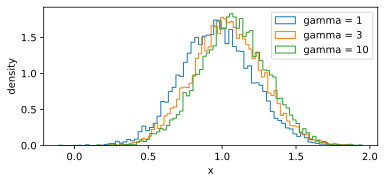

In [6]:
rng = np.random.default_rng(23)

def cfg_sample(gamma, n=8000):                # ancestral chain, guided score
    xt = rng.standard_normal(n)
    for t in range(999, -1, -1):
        a, b = alpha_bar[t], beta[t]
        v = a * vt + 1 - a
        s_uncond = mixture_score(xt, v, (-np.sqrt(a) * mt, np.sqrt(a) * mt))
        s_cond = (np.sqrt(a) * mt - xt) / v   # class y = the right mode
        s = (1 - gamma) * s_uncond + gamma * s_cond
        xt = (xt + b * s) / np.sqrt(1 - b)
        if t > 0:
            xt = xt + np.sqrt(b) * rng.standard_normal(n)
    return xt

samples = {g: cfg_sample(g) for g in (1.0, 3.0, 10.0)}
for g, xs in samples.items():
    print(f'gamma = {g:4.1f}: mass right of 0: {(xs > 0).mean():.3f}, '
          f'mean {xs.mean():.3f}, std {xs.std():.3f}')
print(f'exact conditional: mean {mt:.3f}, std {np.sqrt(vt):.3f}')
d2l.set_figsize((6, 2.5))
for g, xs in samples.items():
    d2l.plt.hist(xs, bins=80, density=True, histtype='step',
                 label=f'gamma = {g:g}')
d2l.plt.xlabel('x'), d2l.plt.ylabel('density'), d2l.plt.legend();

The printout is the tilt, measured. At $\gamma = 1$ the sampler reproduces the
exact conditional: mean $0.966$ against the analytic $0.970$, standard
deviation $0.244$ against $0.243$, and *all* of the mass in the right mode,
where the unconditional mixture would put only half of it. Pushing $\gamma$ to
$3$ and $10$ has no more mass to reallocate, so it distorts the surviving mode
instead: the mean slides from $0.97$ to $1.04$ to $1.07$, away from the class
boundary ("more prototypically $y$") while the histogram narrows slightly.
That drifting, sharpening mode is the caveat above in numbers:
for $\gamma > 1$ the samples track no noised marginal of any clean
distribution; the tilt is its own object, more emphatic and less diverse than
the class it names.

## Flow Matching and Rectified Flow

### Probability Paths and Velocity Fields

Diffusion *derives* its bridge between noise and data from a stochastic
process, then reverses it. Flow matching [@Lipman.Chen.BenHamu.ea.2022]
asks the question directly: *prescribe* a family of densities
$(p_t)_{t \in [0, 1]}$ with $p_0$ = noise and $p_1$ = data (a
**probability path**) and learn the velocity field that transports mass along
it. Recall from that section that a velocity field
$\mathbf{u}_t$ realizes the path iff the pair satisfies the continuity
equation $\partial_t p_t = -\nabla \cdot (p_t\, \mathbf{u}_t)$. If we can fit
$\mathbf{v}_{\boldsymbol{\theta}} \approx \mathbf{u}_t$, generation is a plain
ODE solve of $\dot{\mathbf{x}} = \mathbf{v}_{\boldsymbol{\theta}}(\mathbf{x}, t)$
from $\mathbf{x}_0 \sim p_0$: a continuous normalizing flow
(that section) trained *without ever
simulating the ODE*. The natural objective is the **flow-matching loss**

$$
\mathcal{L}_{\mathrm{FM}}(\boldsymbol{\theta})
= \mathbb{E}_{t \sim \mathcal{U}[0,1],\ \mathbf{x} \sim p_t}
\left[\, \left\| \mathbf{v}_{\boldsymbol{\theta}}(\mathbf{x}, t) - \mathbf{u}_t(\mathbf{x}) \right\|^2 \right],
$$

and it has exactly the problem that explicit score matching had: the marginal
velocity $\mathbf{u}_t$ is unknown. The fix is also the same. Build the path
out of *conditional* paths, one per data point: pick
$p_t(\mathbf{x} \mid \mathbf{z})$, a little moving blob that starts spread as
noise and collapses onto the conditioning variable $\mathbf{z}$ (say, a data
point $\mathbf{x}_1$, or a pair $(\mathbf{x}_0, \mathbf{x}_1)$), whose
conditional velocity $\mathbf{u}_t(\mathbf{x} \mid \mathbf{z})$ we can write
down, and let the marginal path be the mixture
$p_t(\mathbf{x}) = \int p_t(\mathbf{x} \mid \mathbf{z})\, q(\mathbf{z})\, d\mathbf{z}$.

**Proposition (the marginal velocity is a posterior mean).** *Suppose each
conditional pair satisfies the continuity equation,
$\partial_t p_t(\mathbf{x} \mid \mathbf{z}) = -\nabla \cdot \left( p_t(\mathbf{x} \mid \mathbf{z})\, \mathbf{u}_t(\mathbf{x} \mid \mathbf{z}) \right)$,
with integrability sufficient to differentiate the mixture under the integral
sign, and define on $\{p_t > 0\}$ the* **marginal velocity**

$$
\mathbf{u}_t(\mathbf{x})
= \mathbb{E}\left[ \mathbf{u}_t(\mathbf{x} \mid \mathbf{z}) \mid \mathbf{x}_t = \mathbf{x} \right]
= \int \mathbf{u}_t(\mathbf{x} \mid \mathbf{z})\,
\frac{p_t(\mathbf{x} \mid \mathbf{z})\, q(\mathbf{z})}{p_t(\mathbf{x})}\, d\mathbf{z}.
$$

*Then $(p_t, \mathbf{u}_t)$ satisfies the continuity equation: the averaged
field transports the averaged path.*

**Proof.** Differentiate the mixture under the integral sign and substitute
the conditional continuity equation:

$$
\partial_t p_t(\mathbf{x})
= \int \partial_t p_t(\mathbf{x} \mid \mathbf{z})\, q(\mathbf{z})\, d\mathbf{z}
= -\nabla \cdot \int p_t(\mathbf{x} \mid \mathbf{z})\, \mathbf{u}_t(\mathbf{x} \mid \mathbf{z})\, q(\mathbf{z})\, d\mathbf{z}
= -\nabla \cdot \left( p_t(\mathbf{x})\, \mathbf{u}_t(\mathbf{x}) \right),
$$

where the last step is the definition the equation.
$\blacksquare$

### The Conditional Flow Matching Theorem

We now have a target that is an intractable posterior mean
the equation of a tractable per-sample quantity, exactly
the situation the regression lemma the equation was made
for. Define the **conditional flow matching** loss, which needs only samples
$(t, \mathbf{z}, \mathbf{x})$ and the closed-form conditional velocity:

$$
\mathcal{L}_{\mathrm{CFM}}(\boldsymbol{\theta})
= \mathbb{E}_{t,\ \mathbf{z} \sim q,\ \mathbf{x} \sim p_t(\cdot \mid \mathbf{z})}
\left[\, \left\| \mathbf{v}_{\boldsymbol{\theta}}(\mathbf{x}, t) - \mathbf{u}_t(\mathbf{x} \mid \mathbf{z}) \right\|^2 \right].
$$

**Theorem (CFM trains the marginal field).** *Under the integrability needed
for the equation to exist,*

$$
\mathcal{L}_{\mathrm{CFM}}(\boldsymbol{\theta})
= \mathcal{L}_{\mathrm{FM}}(\boldsymbol{\theta}) + C
$$

*with $C$ independent of $\boldsymbol{\theta}$. In particular
$\nabla_{\boldsymbol{\theta}} \mathcal{L}_{\mathrm{CFM}} = \nabla_{\boldsymbol{\theta}} \mathcal{L}_{\mathrm{FM}}$:
the two objectives have identical gradients and identical minimizers*
[@Lipman.Chen.BenHamu.ea.2022; @Tong.Fatras.Malkin.ea.2023].

**Proof.** Apply the regression lemma the equation with
$X = (\mathbf{x}, t)$ where $\mathbf{x} \sim p_t(\cdot \mid \mathbf{z})$, and
$Y = \mathbf{u}_t(\mathbf{x} \mid \mathbf{z})$. The marginal distribution of
$X$ is $t \sim \mathcal{U}[0,1]$, $\mathbf{x} \sim p_t$, and the conditional
mean of $Y$ given $X = (\mathbf{x}, t)$ is, by definition,
the equation, the marginal velocity. The lemma splits
$\mathcal{L}_{\mathrm{CFM}}$ into
$\mathbb{E}\| \mathbf{v}_{\boldsymbol{\theta}}(X) - \mathbf{u}_t(\mathbf{x}) \|^2 = \mathcal{L}_{\mathrm{FM}}$
plus the posterior variance term
$C = \mathbb{E}\| Y - \mathbf{u}_t(\mathbf{x}) \|^2$, which does not involve
$\boldsymbol{\theta}$. $\blacksquare$

Compare this proof with Vincent's theorem: same lemma, same structure, with
(score of the noising kernel $\to$ marginal score) replaced by (conditional
velocity $\to$ marginal velocity). Denoising score matching *is* conditional
flow matching for the score field; the flow-matching literature made the trick
generic. And as before, the theorem's constant $C$ is the irreducible variance
of the conditional target: the CFM training loss plateaus well above zero even
for a perfect model, at the average disagreement among the conditional
velocities passing through each point.

### Score, Noise, and Velocity Are One Function

Diffusion trains a score; flow matching trains a velocity. For the Gaussian
paths that dominate practice these are one
function wearing different clothes, and the conversions can be enumerated.
Condition on a data point and take the Gaussian path

$$
\mathbf{x}_t = \alpha_t\, \mathbf{x}_1 + \sigma_t\, \boldsymbol{\epsilon},
\qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, I),
$$

with smooth schedules $(\alpha_t, \sigma_t)$: on the flow-matching clock
$(\alpha_0, \sigma_0) = (0, 1)$ and $(\alpha_1, \sigma_1) = (1, 0)$; on the
diffusion clock, write $\mathbf{x}_0$ for the data point and swap the boundary
conditions, and every formula below holds verbatim.

**Proposition (score–velocity identity).** *For the Gaussian path above, at
any $t$ with $\alpha_t, \sigma_t > 0$ and on $\{p_t > 0\}$, the marginal
velocity the equation and the marginal score determine
each other:*

$$
\mathbf{u}_t(\mathbf{x})
= \frac{\dot{\alpha}_t}{\alpha_t}\, \mathbf{x}
- \left( \sigma_t \dot{\sigma}_t - \sigma_t^2\, \frac{\dot{\alpha}_t}{\alpha_t} \right)
\nabla \log p_t(\mathbf{x}).
$$

**Proof.** Both sides are posterior expectations given
$\mathbf{x}_t = \mathbf{x}$, and both are affine in the same one: write
$\hat{\mathbf{x}}_1 = \mathbb{E}[\mathbf{x}_1 \mid \mathbf{x}_t = \mathbf{x}]$.
Differentiating the path gives the conditional velocity
$\dot{\mathbf{x}}_t = \dot{\alpha}_t \mathbf{x}_1 + \dot{\sigma}_t \boldsymbol{\epsilon}$
with $\boldsymbol{\epsilon} = (\mathbf{x} - \alpha_t \mathbf{x}_1)/\sigma_t$,
so taking the posterior mean in the equation,

$$
\mathbf{u}_t(\mathbf{x})
= \frac{\dot{\sigma}_t}{\sigma_t}\, \mathbf{x}
+ \left( \dot{\alpha}_t - \alpha_t\, \frac{\dot{\sigma}_t}{\sigma_t} \right) \hat{\mathbf{x}}_1.
$$

Meanwhile the marginal score is the posterior mean of the conditional scores
(Vincent's theorem, verbatim), and the conditional score of the kernel
$\mathcal{N}(\alpha_t \mathbf{x}_1, \sigma_t^2 I)$ is
$(\alpha_t \mathbf{x}_1 - \mathbf{x})/\sigma_t^2$, so Tweedie's formula for
this kernel reads

$$
\nabla \log p_t(\mathbf{x})
= \mathbb{E}\left[ \frac{\alpha_t \mathbf{x}_1 - \mathbf{x}}{\sigma_t^2} \,\middle|\, \mathbf{x}_t = \mathbf{x} \right]
= \frac{\alpha_t \hat{\mathbf{x}}_1 - \mathbf{x}}{\sigma_t^2},
\qquad \textrm{i.e.}\quad
\hat{\mathbf{x}}_1 = \frac{\mathbf{x} + \sigma_t^2\, \nabla \log p_t(\mathbf{x})}{\alpha_t}.
$$

Substitute this into the velocity display above and collect the $\mathbf{x}$
and $\nabla \log p_t$ terms: the equation falls out.
$\blacksquare$

The same posterior mean $\hat{\mathbf{x}}_1$ underlies every parameterization a
practitioner meets, so the parameterizations are inter-convertible by
$t$-dependent affine maps of one function:

| Network predicts | Posterior meaning | From the score $\mathbf{s} = \nabla \log p_t$ |
| :-- | :-- | :-- |
| score $\mathbf{s}_{\boldsymbol{\theta}}$ | $\nabla \log p_t(\mathbf{x})$ | $\mathbf{s}$ |
| noise $\hat{\boldsymbol{\epsilon}}$ | $\mathbb{E}[\boldsymbol{\epsilon} \mid \mathbf{x}_t = \mathbf{x}]$ | $-\sigma_t\, \mathbf{s}$ |
| clean point $\hat{\mathbf{x}}_1$ | $\mathbb{E}[\mathbf{x}_1 \mid \mathbf{x}_t = \mathbf{x}]$ | $(\mathbf{x} + \sigma_t^2\, \mathbf{s})/\alpha_t$ (Tweedie) |
| velocity $\mathbf{v}_{\boldsymbol{\theta}}$ | $\mathbb{E}[\dot{\mathbf{x}}_t \mid \mathbf{x}_t = \mathbf{x}]$ | the identity the equation |
| $v$-prediction $\hat{\mathbf{v}}$ | $\mathbb{E}[\alpha_t \boldsymbol{\epsilon} - \sigma_t \mathbf{x}_1 \mid \mathbf{x}_t = \mathbf{x}]$ | $-\tfrac{\sigma_t}{\alpha_t}\, \mathbf{x} - \sigma_t\, \tfrac{\alpha_t^2 + \sigma_t^2}{\alpha_t}\, \mathbf{s}$ |

Which target to train on is a conditioning question, not a modeling one. Near
the data end ($\sigma_t \to 0$) the score blows up like $1/\sigma_t$ while
$\boldsymbol{\epsilon}$ stays unit-scale, so $\hat{\boldsymbol{\epsilon}}$-prediction
(DDPM's choice) hands the network a well-scaled regression target at exactly
the low-noise levels where perceptual detail is decided. But near the noise end
($\alpha_t \to 0$) recovering $\hat{\mathbf{x}}_1$ from
$\hat{\boldsymbol{\epsilon}}$ divides by $\alpha_t$, so an
$\hat{\boldsymbol{\epsilon}}$-network barely constrains the clean prediction
there. The $v$-**prediction** target
$\mathbf{v} = \alpha_t \boldsymbol{\epsilon} - \sigma_t \mathbf{x}_1$ is the
blend that stays order-one at *both* ends, which is why *distillation*
(training a student network to reproduce many solver steps of a teacher in
one) and many production systems train it [@Salimans.Ho.2022].

One invariant clock underlies all the schedules. Define the **log
signal-to-noise ratio** $\lambda_t = \log(\alpha_t^2 / \sigma_t^2)$ (not to be
confused with the loss weighting $\lambda(t)$; the field's notation
overloads the letter), which runs monotonically from data
($\lambda = +\infty$) to noise. Every conversion factor in the dictionary, and
the noised density itself after rescaling by $\alpha_t$, depends on $t$ only
through $\lambda_t$: two schedules that traverse the same range of $\lambda$
are *time reparameterizations of the same family of models*, differing only in
how training effort and solver steps are spread over noise levels
[@Kingma.Salimans.Poole.ea.2021]. The schedule $\sigma(t) = t$ with
$\alpha_t \equiv 1$ of EDM (the "elucidating diffusion models" design study
of [@Karras.Aittala.Aila.ea.2022]) is exactly such a
re-clocking, chosen to make the sampler's job easy; we will meet its Heun
sampler at the end of the section.

The identity is checkable to machine precision with the section's own mixture:
at a fixed $t$, compute the marginal velocity once from the posterior mean
(route one, no score in sight) and once from the dictionary formula
the equation with the analytic score (route two, no
velocity in sight).

In [7]:
t = 0.6                                       # one fixed time, cosine schedule
alpha, sigma = np.sin(np.pi * t / 2), np.cos(np.pi * t / 2)
dalpha, dsigma = np.pi / 2 * sigma, -np.pi / 2 * alpha
grid = np.linspace(-4.0, 4.0, 201)
means, var0 = np.array([-2.0, 2.0]), 0.25     # the mixture of the DSM demo
vart = alpha**2 * var0 + sigma**2             # noised component variance
w = np.stack([np.exp(-(grid - alpha * m)**2 / (2 * vart)) for m in means])
w /= w.sum(0)                                 # posterior mode responsibilities
x1_hat = (w * np.stack([m + alpha * var0 / vart * (grid - alpha * m)
                        for m in means])).sum(0)          # E[x_1 | x_t]
u_posterior = dalpha * x1_hat + dsigma / sigma * (grid - alpha * x1_hat)
score = (w * np.stack([(alpha * m - grid) / vart for m in means])).sum(0)
u_dictionary = (dalpha / alpha) * grid \
    - (sigma * dsigma - sigma**2 * dalpha / alpha) * score
print(f'max |u_posterior - u_dictionary| on [-4, 4]: '
      f'{np.abs(u_posterior - u_dictionary).max():.1e}')

max |u_posterior - u_dictionary| on [-4, 4]: 3.1e-15


The two routes agree to about $10^{-15}$ (machine precision) across both
modes and the low-density valley. Nothing was fitted: the posterior route never
mentions a score, the dictionary route never mentions a velocity, and they
trace the same curve because both are affine in the one quantity
$\hat{x}_1$ that the posterior knows. When a paper says its model "predicts
noise" and a library says it "trains a velocity field", this cell is the
translation between them.

### Rectified Flow and Straight Paths

Everything now rests on the choice of conditional path, and the simplest
choice is hard to beat. Condition on a *pair*
$\mathbf{z} = (\mathbf{x}_0, \mathbf{x}_1)$, a noise sample and a data
sample drawn independently, and connect them by a straight line traversed at
constant speed:

$$
\mathbf{x}_t = (1 - t)\, \mathbf{x}_0 + t\, \mathbf{x}_1,
\qquad
\mathbf{u}_t(\mathbf{x}_t \mid \mathbf{z}) = \dot{\mathbf{x}}_t = \mathbf{x}_1 - \mathbf{x}_0.
$$

The conditional velocity does not even depend on $t$: the CFM loss
the equation becomes the **rectified flow** (equivalently,
linear-path CFM) objective
[@Liu.Gong.Liu.2022; @Lipman.Chen.BenHamu.ea.2022]

$$
\mathcal{L}_{\mathrm{RF}}(\boldsymbol{\theta})
= \mathbb{E}_{t,\ \mathbf{x}_0 \sim p_0,\ \mathbf{x}_1 \sim p_1}
\left[\, \left\| \mathbf{v}_{\boldsymbol{\theta}}\big( (1 - t) \mathbf{x}_0 + t \mathbf{x}_1,\ t \big)
- (\mathbf{x}_1 - \mathbf{x}_0) \right\|^2 \right]
$$

Training is one line: draw noise,
draw data, interpolate, regress on the difference. (For the measure-theoretic
comfort of strictly positive conditional densities, smooth the line with an
infinitesimal Gaussian, $p_t(\cdot \mid \mathbf{z}) = \mathcal{N}((1-t)\mathbf{x}_0 + t \mathbf{x}_1, \sigma_{\min}^2 I)$,
and let $\sigma_{\min} \to 0$; nothing below changes. Gaussian conditional
paths with general $(\mu_t, \sigma_t)$ schedules recover diffusion-style
targets: that is how flow matching subsumes the VP path, modulo the
time-reversal callout above.)

![Straight conditional segments connecting independent noise--data pairs cross each other; the marginal flow they induce cannot cross itself, so it bends, averaging the directions of the segments passing through each point. Reflow re-couples endpoints using the model's own ODE, straightening the learned paths.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-fm-paths.svg)

A subtlety (the figure): the *conditional* paths are straight, but the *marginal*
flow that the network learns is generally **curved**. Two straight segments
that cross at $(\mathbf{x}, t)$ feed the posterior mean
the equation two different directions, and the learned
field (which, like any function, can have only one value there) averages
them. An ODE's trajectories cannot cross (uniqueness,
that section), so the learned flow bends to
avoid the collisions that the conditional segments ignore. The independent
coupling of $\mathbf{x}_0$ and $\mathbf{x}_1$ produces many crossings, hence
real curvature, hence many Euler steps at sampling time. **Reflow**
[@Liu.Gong.Liu.2022] attacks the coupling: after training, generate pairs
$(\mathbf{x}_0, \hat{\mathbf{x}}_1)$ by *running your own ODE*, and retrain on
this new coupling, in which start and end points are already dynamically
matched. Each round provably leaves the marginals intact, never increases any
convex transport cost, and straightens the paths, toward the
straight-by-construction transport that the next section identifies as optimal.
In the straight limit, one Euler step is exact (the local truncation error of
Euler is controlled by the curvature $\ddot{\mathbf{x}}$ along trajectories,
that section); this is the mathematics behind few-step
and one-step generators distilled from flows.

### Gaussian to Two Moons, Four Ways

Time to train one. The target is a two-moons distribution (two interleaved
crescents, a classic stress test for mode-splitting) generated in a few lines
of NumPy; the source is a standard 2-D Gaussian. We also define the **energy
distance**
$\mathcal{E}(P, Q) = \left( 2\, \mathbb{E}\|X - Y\| - \mathbb{E}\|X - X'\| - \mathbb{E}\|Y - Y'\| \right)^{1/2}$
[@Szekely.Rizzo.2013], an MMD-style two-sample discrepancy
(that section) that is zero iff the distributions agree; we use
its square, on $2048$-point samples, to grade generated samples against a
held-out target sample throughout.

In [8]:
def two_moons(n, rng, noise=0.07):
    t = rng.uniform(0.0, np.pi, n)
    m = rng.integers(0, 2, n)                      # which moon
    X = np.stack([np.cos(t) * (1 - 2 * m) + m,
                  np.sin(t) * (1 - 2 * m) + 0.5 * m], axis=1)
    return X + noise * rng.standard_normal((n, 2))

rng = np.random.default_rng(0)
raw = two_moons(8192, rng)
mu, sd = raw.mean(0), raw.std(0)
moons = (raw - mu) / sd                            # standardized training data
held_out = (two_moons(2048, np.random.default_rng(1)) - mu) / sd

def energy_distance(a, b):                         # squared energy distance
    d = lambda u, v: np.linalg.norm(u[:, None, :] - v[None, :, :], axis=-1).mean()
    return 2 * d(a, b) - d(a, a) - d(b, b)

print(f'training set {moons.shape}; energy distance of a fresh sample '
      f'to the held-out set: {energy_distance(moons[:2048], held_out):.4f}')

training set (8192, 2); energy distance of a fresh sample to the held-out set: 0.0014


The fresh-sample-to-held-out value ($\approx 0.001$) is the noise floor: no
generator can reliably beat it. Now the model, a velocity field
$\mathbf{v}_{\boldsymbol{\theta}} : \mathbb{R}^2 \times [0, 1] \to \mathbb{R}^2$
as a $3 \to 64 \to 64 \to 2$ tanh MLP, trained for $4000$ Adam steps on the
rectified-flow objective the equation. Each batch is literally the
recipe: sample $\mathbf{x}_0$, $\mathbf{x}_1$, $t$; interpolate; regress on
$\mathbf{x}_1 - \mathbf{x}_0$. This is the section's second training loop (the
NumPy score network was the first), and it takes a few seconds on a CPU.

In [9]:
def init_mlp(key, sizes=(3, 64, 64, 2)):
    keys = jax.random.split(key, len(sizes) - 1)
    return [(jax.random.normal(k, (i, o)) / jnp.sqrt(i), jnp.zeros(o))
            for k, i, o in zip(keys, sizes[:-1], sizes[1:])]

def mlp(params, x):
    for W, b in params[:-1]:
        x = jnp.tanh(x @ W + b)
    return x @ params[-1][0] + params[-1][1]

data = jnp.asarray(moons, dtype=jnp.float32)

def cfm_loss(params, key):
    k1, k2, k3 = jax.random.split(key, 3)
    x1 = data[jax.random.randint(k1, (256,), 0, len(data))]
    x0 = jax.random.normal(k2, (256, 2))
    t = jax.random.uniform(k3, (256, 1))
    xt = (1 - t) * x0 + t * x1
    v = mlp(params, jnp.concatenate([xt, t], axis=1))
    return ((v - (x1 - x0))**2).mean()

opt = optax.adam(3e-3)
params = init_mlp(jax.random.key(0))
state = opt.init(params)

@jax.jit
def train(params, state, key):
    def step(carry, k):
        params, state = carry
        loss, grads = jax.value_and_grad(cfm_loss)(params, k)
        updates, state = opt.update(grads, state)
        return (optax.apply_updates(params, updates), state), loss
    return jax.lax.scan(step, (params, state), jax.random.split(key, 4000))

(params, state), losses = train(params, state, jax.random.key(1))
print(f'CFM loss: step 0 {losses[0]:.3f} -> step 4000 {losses[-1]:.3f}')

CFM loss: step 0 1.908 -> step 4000 1.402


The loss falls from about $2$ to about $1.3$ and stops: the plateau the CFM
theorem predicted, sitting at the variance of $\mathbf{x}_1 - \mathbf{x}_0$
around its posterior mean, not at zero. Sampling is an Euler loop
(that section) integrating
$\dot{\mathbf{x}} = \mathbf{v}_{\boldsymbol{\theta}}(\mathbf{x}, t)$ from
$t = 0$ to $1$, and the panels below show the entire speed/quality trade-off
at a glance: one step produces a smeared blob, two steps a bent ellipse, eight
steps recognizable moons, thirty-two steps sharp ones.

In [10]:
velocity = jax.jit(
    lambda params, q, t: mlp(params, jnp.concatenate([q, t], axis=1)))

def euler_sample(n, steps, seed=2):
    q = jax.random.normal(jax.random.key(seed), (n, 2))
    for k in range(steps):
        q = q + (1.0 / steps) * velocity(params, q, jnp.full((n, 1), k / steps))
    return np.asarray(q)

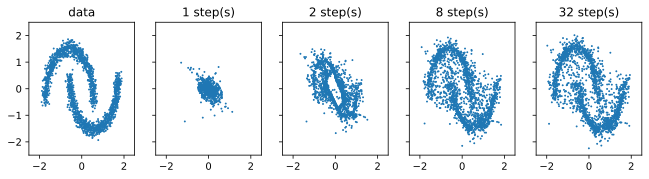

In [11]:
panels = [('data', moons[:2048])] + [
    (f'{K} step(s)', euler_sample(2048, K)) for K in (1, 2, 8, 32)]
fig, axes = d2l.plt.subplots(1, 5, figsize=(11, 2.4), sharex=True, sharey=True)
for ax, (title, s) in zip(axes, panels):
    ax.scatter(s[:, 0], s[:, 1], s=1)
    ax.set_title(title)
    ax.set_xlim(-2.5, 2.5), ax.set_ylim(-2.5, 2.5)

That a few Euler steps already work, where a comparable diffusion sampler
would want dozens to hundreds, is the linear path keeping the learned flow
only mildly curved. How mildly, and what it costs to be curved at all, is a
question about optimal transport.

### One Reflow Round, Measured

Before leaving the trained model, we can test rectified flow's central claim,
that reflow straightens the learned paths. Run the procedure of
that section literally: draw fresh noise $\mathbf{z}$,
integrate the trained ODE for $32$ Euler steps to obtain the model's own
endpoint $\hat{\mathbf{x}}_1(\mathbf{z})$, and retrain the *same architecture*
on the coupled pairs $(\mathbf{z}, \hat{\mathbf{x}}_1(\mathbf{z}))$ in place of
independent ones. If the new couplings rarely cross, the retrained flow should
be nearly straight, and a nearly straight flow should sample well in *one*
Euler step.

In [12]:
z = jax.random.normal(jax.random.key(3), (8192, 2))   # noise endpoints, kept
x1_hat = z
for k in range(32):                                # the model's own couplings
    x1_hat = x1_hat + (1.0 / 32) * velocity(params, x1_hat,
                                            jnp.full((8192, 1), k / 32))

def reflow_loss(params2, key):
    k1, k2 = jax.random.split(key)
    i = jax.random.randint(k1, (256,), 0, len(z))
    x0, x1 = z[i], x1_hat[i]                       # the same pair, never re-paired
    t = jax.random.uniform(k2, (256, 1))
    xt = (1 - t) * x0 + t * x1
    v = mlp(params2, jnp.concatenate([xt, t], axis=1))
    return ((v - (x1 - x0))**2).mean()

params2 = init_mlp(jax.random.key(4))
state2 = opt.init(params2)

@jax.jit
def retrain(params2, state2, key):
    def step(carry, k):
        params2, state2 = carry
        loss, grads = jax.value_and_grad(reflow_loss)(params2, k)
        updates, state2 = opt.update(grads, state2)
        return (optax.apply_updates(params2, updates), state2), loss
    return jax.lax.scan(step, (params2, state2), jax.random.split(key, 4000))

(params2, state2), losses = retrain(params2, state2, jax.random.key(5))
print(f'final reflow loss {losses[-1]:.3f}')

def euler_sample2(n, steps, seed=2):
    q = jax.random.normal(jax.random.key(seed), (n, 2))
    for k in range(steps):
        q = q + (1.0 / steps) * velocity(params2, q, jnp.full((n, 1), k / steps))
    return np.asarray(q)

for K in (1, 2, 32):
    print(f'{K:2d} step(s): energy distance  '
          f'CFM {energy_distance(euler_sample(2048, K), held_out):.3f}  ->  '
          f'reflow {energy_distance(euler_sample2(2048, K), held_out):.3f}')

final reflow loss 0.001


 1 step(s): energy distance  CFM 0.657  ->  reflow 0.005


 2 step(s): energy distance  CFM 0.175  ->  reflow 0.004


32 step(s): energy distance  CFM 0.004  ->  reflow 0.004


The collapse is total (numbers from one run; repeat runs agree up to
Monte-Carlo and initialization noise): one Euler step of the reflowed model
scores $0.016$, within noise of the original model's $32$-step quality of
$0.014$, and forty times better than the original one-step $0.676$. The
training loss tells the same story from the other side: it falls to about
$0.001$ instead of plateauing near $1.3$, because the model-generated coupling
is essentially deterministic: almost no two segments cross, so the posterior
variance that set the CFM floor is gone. Two caveats. Rectified flow's
guarantee (marginals preserved, convex transport costs never increased, paths
straightened) holds for exact velocities, and full straightness is a limit
over rounds; what we measured is one finite round of an imperfectly trained
model. And the retrained target is the model's $32$-step endpoint law, not the
data law, so the first model's small bias is now baked in: invisible at
two-moons scale, but the reason production reflow pipelines follow up with a
fine-tune on real couplings.

## Optimal Transport and Straightness

Why should straight paths be the gold standard, and in what precise sense is
"straight" optimal? The answers come from optimal transport. We keep this
self-contained: that section develops the
Kantorovich-dual $W_1$ picture behind WGANs, but here we need the *quadratic*
cost and its dynamic, fluid-flow formulation.

A **coupling** of two distributions $p_0, p_1$ on $\mathbb{R}^d$ is a joint
distribution $\pi$ with marginals $p_0$ and $p_1$, a randomized
transportation plan saying how much mass travels from each source location to
each destination. The **2-Wasserstein distance** is the cheapest plan under
quadratic cost:

$$
W_2^2(p_0, p_1) = \min_{\pi \in \Pi(p_0, p_1)}\ \mathbb{E}_{(\mathbf{x}_0, \mathbf{x}_1) \sim \pi}
\left[\, \| \mathbf{x}_1 - \mathbf{x}_0 \|^2 \right].
$$

(Under mild conditions, e.g. $p_0$ with a density, the optimal plan is
deterministic, a *map* $\mathbf{x}_1 = T(\mathbf{x}_0)$ with $T$ the gradient
of a convex function; that is Brenier's theorem [@Brenier.1991], and we
will not need it beyond intuition.) What we need is the reformulation of
the equation as a *least-action principle over flows*, due to
@Benamou.Brenier.2000: the static matching problem equals
a minimum over exactly the objects flow matching trains.

**Theorem (Benamou–Brenier, dynamic formulation).** *Let $p_0$ and $p_1$
have finite second moments. Over all pairs $(p_t, \mathbf{v}_t)$, regular
enough that the flow of $\mathbf{v}_t$ exists, satisfying the continuity
equation $\partial_t p_t = -\nabla \cdot (p_t \mathbf{v}_t)$ with the
prescribed endpoints $p_0$ and $p_1$,*

$$
W_2^2(p_0, p_1)
= \min_{(p_t, \mathbf{v}_t)}\ \int_0^1 \int \| \mathbf{v}_t(\mathbf{x}) \|^2\, p_t(\mathbf{x})\, d\mathbf{x}\, dt
$$

*The squared distance is the least kinetic energy of any flow carrying $p_0$
to $p_1$, and the minimizing flow transports each particle along a straight
line at constant speed.*

**Proof sketch (the lower bound, via Jensen).** Take any admissible
$(p_t, \mathbf{v}_t)$ and let $\mathbf{X}_t$ solve the ODE
$\dot{\mathbf{X}}_t = \mathbf{v}_t(\mathbf{X}_t)$ with
$\mathbf{X}_0 \sim p_0$. Two facts are granted here: that this ODE is
solvable, and that its law is the continuity equation's unique solution, so
that $\mathbf{X}_t \sim p_t$ for all $t$
(that section; the uniqueness argument is the
probability-flow twin of that section). In
particular $(\mathbf{X}_0, \mathbf{X}_1)$ is a coupling of $(p_0, p_1)$. Then

$$
W_2^2(p_0, p_1)
\le \mathbb{E} \left\| \mathbf{X}_1 - \mathbf{X}_0 \right\|^2
= \mathbb{E} \left\| \int_0^1 \mathbf{v}_t(\mathbf{X}_t)\, dt \right\|^2
\le \mathbb{E} \int_0^1 \left\| \mathbf{v}_t(\mathbf{X}_t) \right\|^2 dt
= \int_0^1\!\! \int \|\mathbf{v}_t\|^2\, p_t\, d\mathbf{x}\, dt,
$$

where the first inequality is suboptimality of this particular coupling and
the second is Jensen's inequality (that section) applied to the
time average inside the squared norm. So *every* admissible flow has kinetic
energy at least $W_2^2$. For the matching upper bound, transport along the
optimal plan in straight lines at constant speed,
$\mathbf{X}_t = (1 - t) \mathbf{X}_0 + t\, \mathbf{X}_1$ with
$(\mathbf{X}_0, \mathbf{X}_1) \sim \pi^\star$: its kinetic energy is
$\mathbb{E} \|\mathbf{X}_1 - \mathbf{X}_0\|^2 = W_2^2$ exactly. (When
$\pi^\star$ is a map, this displacement interpolation is realized by a genuine
velocity field; smoothing handles the general case.)

The equality analysis explains straightness. For a fixed pair of endpoints,
Jensen's inequality is tight iff the particle has constant velocity, hence
follows their straight segment. Attaining the global $W_2^2$ floor additionally
requires an *optimal endpoint coupling*. Curvature raises the kinetic energy
for a fixed coupling, but straight segments under an arbitrary coupling need
not be optimal transport. In this light the methods of this section line up as
one program:

* **Diffusion / probability-flow trajectories** are curved (the VP path
  spirals mass inward), so they pay both extra kinetic energy and, by the
  Euler error analysis of that section, extra solver
  steps.
* **Rectified flow** starts from straight *conditional* segments (each pair in
  the equation is a constant-speed line), while averaging velocities
  at locations reached by several pairs can bend the learned marginal flow.
  **Reflow** often reduces this curvature by replacing independent pairs with
  pairs generated by the current model. It does not by itself certify the
  optimal-transport coupling; in more than one dimension, noncrossing alone
  implies neither straightness nor optimality.
* **Minibatch OT couplings** attack the same waste before training: within
  each batch, re-pair the noise and data samples by solving a small discrete
  OT problem (an assignment over $256$ points) and run CFM on the matched
  pairs [@Tong.Fatras.Malkin.ea.2023; @Pooladian.BenHamu.DomingoEnrich.ea.2023].
  Matched pairs rarely cross, so the marginal field is born nearly straight:
  the batch-sized approximation to the Benamou–Brenier minimizer.

One caveat: exact OT in high dimension is expensive
and minibatch plans are biased toward their batch, so OT-CFM and reflow are
best read as *variance- and curvature-reduction devices* with the dynamic OT
problem as their idealized limit, not as exact $W_2$ solvers.

## Sampling Is Solving the Learned Dynamics

Training produced a function: a score $\mathbf{s}_{\boldsymbol{\theta}}$ or a
velocity $\mathbf{v}_{\boldsymbol{\theta}}$. Generation, in every model of
this section, is the *same act*: plug the function into the dynamics and
integrate from the easy distribution to the hard one,

$$
\underbrace{\dot{\mathbf{x}} = \mathbf{v}_{\boldsymbol{\theta}}(\mathbf{x}, t)
\quad \textrm{or} \quad
\dot{\mathbf{x}} = \mathbf{f} - \tfrac{1}{2} g^2\, \mathbf{s}_{\boldsymbol{\theta}}}_{\textrm{deterministic (ODE)}}
\qquad \textrm{versus} \qquad
\underbrace{d\mathbf{x} = \left[ \mathbf{f} - g^2\, \mathbf{s}_{\boldsymbol{\theta}} \right] dt + g\, d\bar{\mathbf{W}}}_{\textrm{stochastic (reverse SDE)}},
$$

with $\mathbf{f}$ and $g$ the forward drift and diffusion of
that section and $\bar{\mathbf{W}}$ a reverse-time Brownian motion:
the stochastic branch is Anderson's reverse SDE
the equation, and both branches reuse, unchanged, the
solvers of that section and
that section. The ODE route is deterministic (the same
$\mathbf{x}_T$ yields the same sample, useful for interpolation and editing)
and often works with fewer steps for suitably trained, low-curvature fields.
It also supports likelihood evaluation through the continuous-normalizing-flow
trace integral of that section; this is exact
only for the exact field, divergence, and numerical integration. The SDE route
injects fresh noise and can improve exploration or empirical robustness, but
noise does not universally contract model or discretization error, nor does it
by itself guarantee sample diversity. Predictor–corrector methods combine the
two styles. The remaining dial is the number of
steps, and we can now measure exactly what it buys. The cell reuses the
trained two-moons velocity field and grades Euler sampling at increasing step
counts with the squared energy distance.

1: 0.657  2: 0.175  4: 0.044  8: 0.013  16: 0.006  32: 0.004  64: 0.003


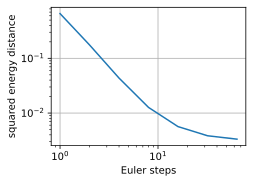

In [13]:
steps_list = [1, 2, 4, 8, 16, 32, 64]
eds = [energy_distance(euler_sample(2048, K), held_out) for K in steps_list]
print('  '.join(f'{K}: {e:.3f}' for K, e in zip(steps_list, eds)))
d2l.plot(steps_list, eds, 'Euler steps', 'squared energy distance',
         xscale='log', yscale='log')

The squared energy distance falls from $0.68$ at one step
to $0.16$ at two and $0.05$ at four, reaches $0.02$ by eight, and flattens
near $0.015$ from sixteen steps on (numbers from one run; repeat runs agree
up to Monte-Carlo noise). Read the two regimes off the curve: to the left,
error is dominated by the *solver* and drops roughly like the $O(h)$ Euler
analysis predicts; the plateau on the right is the *model's* bias: more steps
cannot fix a field that is slightly wrong, only more training can (compare
the $0.001$ noise floor printed earlier).

Solver order is the other lever. The probability-flow ODE with the *exact*
score of our 1-D mixture under the VP schedule lets us isolate pure
discretization error, with no learning in the loop. We integrate from $t = 1$
(noise) to $t = 0$ (data) with Euler and with Heun's method, the
order-2 scheme of that section at two field evaluations
(NFE) per step, and measure the endpoint error against a finely-resolved
reference solution of the same initial points.

In [14]:
rng = np.random.default_rng(17)
bmin, bmax = 0.1, 20.0
beta_fn = lambda t: bmin + t * (bmax - bmin)            # VP noise schedule
abar_fn = lambda t: np.exp(-(bmin * t + 0.5 * (bmax - bmin) * t**2))

def score_vp(q, t, means=(-2.0, 2.0), var=0.25):        # exact mixture score
    a = abar_fn(t)
    v = a * var + (1 - a)
    w = np.stack([np.exp(-(q - np.sqrt(a) * m)**2 / (2 * v)) for m in means])
    return (w * np.stack([(np.sqrt(a) * m - q) / v
                          for m in means])).sum(0) / w.sum(0)

def pf_ode(q, t):                                       # probability-flow ODE
    return -0.5 * beta_fn(t) * (q + score_vp(q, t))

def solve(q, K, heun=False):
    ts = np.linspace(1.0, 0.0, K + 1)
    for t1, t2 in zip(ts[:-1], ts[1:]):
        h, d1 = t2 - t1, pf_ode(q, t1)
        q = q + 0.5 * h * (d1 + pf_ode(q + h * d1, t2)) if heun \
            else q + h * d1
    return q

z = rng.standard_normal(8000)
ref = solve(z, 800, heun=True)                          # fine reference
for K in (2, 5, 10, 20, 40):
    print(f'K = {K:2d} steps: endpoint error  '
          f'Euler {np.abs(solve(z, K) - ref).mean():.4f} ({K} NFE)   '
          f'Heun {np.abs(solve(z, K, heun=True) - ref).mean():.4f} ({2 * K} NFE)')

K =  2 steps: endpoint error  Euler 0.7516 (2 NFE)   Heun 0.6659 (4 NFE)
K =  5 steps: endpoint error  Euler 0.1215 (5 NFE)   Heun 0.0808 (10 NFE)
K = 10 steps: endpoint error  Euler 0.0439 (10 NFE)   Heun 0.0282 (20 NFE)
K = 20 steps: endpoint error  Euler 0.0203 (20 NFE)   Heun 0.0085 (40 NFE)
K = 40 steps: endpoint error  Euler 0.0099 (40 NFE)   Heun 0.0023 (80 NFE)


Doubling Euler's steps halves its error (order one); doubling Heun's cuts it
roughly fourfold (order two), so Heun at $20$ steps ($40$ NFE) already beats
Euler at $40$. This is the engine of the EDM sampler
[@Karras.Aittala.Aila.ea.2022]: Heun's method plus a noise schedule
tuned to where the field is stiff yields state-of-the-art images at roughly
$35$ NFE, where DDPM ancestral sampling used a thousand. Beyond that lie the
topics of the main book's generative-models chapters: consistency models,
which distill a diffusion teacher into a one-step generator
[@Song.Dhariwal.Chen.ea.2023]; latent diffusion, which runs all of this
in an autoencoder's latent space [@Rombach.Blattmann.Lorenz.ea.2022];
and discrete diffusion for text [@Austin.Johnson.Ho.ea.2021].

### A Unifying Table

The zoo of this section is one template with three slots (a probability
path, a regression target, a sampler):

| Model family | Object learned | Training loss | Sampler | Stochastic? |
| :-- | :-- | :-- | :-- | :-- |
| **DDPM** [@ho2020denoising] | $\boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t)$, i.e. the score in disguise | $\mathbb{E} \lVert \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_{\boldsymbol{\theta}} \rVert^2$ (= DSM, $\lambda(t) = 1 - \bar{\alpha}_t$) | ancestral reverse chain, $T \sim 1000$ steps | yes |
| **Score SDE (VE/VP)** [@song2021score] | $\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, t) \approx \nabla \log p_t$ | noise-conditional DSM the equation | reverse SDE via Euler–Maruyama; + Langevin corrector | yes |
| **Probability-flow ODE** [@song2021score] | same $\mathbf{s}_{\boldsymbol{\theta}}$ (shared training) | same | ODE solver (Euler/Heun/RK); exact likelihood | no |
| **DDIM** [@Song.Meng.Ermon.2020] | same $\boldsymbol{\epsilon}_{\boldsymbol{\theta}}$ as DDPM (no retraining) | same as DDPM | deterministic update the equation on a sparse time grid | no ($\eta$ interpolates) |
| **Flow matching / rectified flow** [@Lipman.Chen.BenHamu.ea.2022; @Liu.Gong.Liu.2022] | velocity $\mathbf{v}_{\boldsymbol{\theta}}(\mathbf{x}, t)$ | CFM the equation; linear path: $\mathbb{E} \lVert \mathbf{v}_{\boldsymbol{\theta}} - (\mathbf{x}_1 - \mathbf{x}_0) \rVert^2$ | ODE solver, few steps (straighter paths) | no |

Read it column by column and the section compresses to three sentences. Every
*object learned* is a conditional expectation of a closed-form per-sample
quantity. Every *training loss* is least-squares regression onto that
quantity, justified by the regression lemma. Every *sampler* is a numerical
integrator from that section or that section
applied to dynamics in which the learned function is the only unknown, and
the speed of that integrator is governed by the geometry (curvature, hence
optimal transport) of the path the model chose to learn.

The table's two halves (score rows sampled by reversing a stochastic process,
velocity rows sampled by integrating a prescribed path) also admit a single
umbrella: the **stochastic interpolants** of
@Albergo.Boffi.VandenEijnden.2023 write
$\mathbf{x}_t = \alpha_t \mathbf{x}_0 + \beta_t \mathbf{x}_1 + \gamma_t \mathbf{w}$
and recover every row by a choice of schedule, the diffusion rows with
interior noise $\gamma_t > 0$ and the rectified-flow row with
$\gamma_t \equiv 0$. Exercise 8 walks the construction.

## Summary

* The score $\nabla \log p$ is computable without the normalizing constant.
  Explicit score matching minimizes the Fisher divergence; Hyvärinen's
  integration by parts the equation makes it estimable from
  samples, at the price of an $O(d)$ divergence term.
* The **regression lemma**: least squares against a noisy target fits its
  conditional mean. Denoising score matching (target $-\boldsymbol{\epsilon}/\sigma$,
  marginal score = posterior mean of conditional scores) and conditional flow
  matching (target $\mathbf{u}_t(\mathbf{x} \mid \mathbf{z})$, marginal
  velocity = posterior mean of conditional velocities) are the same theorem
  twice, and both losses plateau at the irreducible posterior variance.
* DDPM is the variance-preserving SDE discretized (first order), with an exact
  $\bar{\alpha}$-marginal, and its $\boldsymbol{\epsilon}$-prediction loss is
  reweighted DSM with $\lambda(t) = 1 - \bar{\alpha}_t$; the ELBO derivation
  reaches the same objective.
* A score alone samples via **Langevin dynamics**, whose stationary density is
  $p$ (one-line Fokker–Planck proof) but whose mixing across modes is slow:
  hence annealing over noise levels and predictor–corrector samplers. **DDIM**
  reuses a trained DDPM deterministically with big steps; **guidance** is
  Bayes' rule on scores, with classifier-free guidance an extrapolation
  $(1 - \gamma) \mathbf{s}_\varnothing + \gamma \mathbf{s}_y$.
* Flow matching prescribes the path and regresses the velocity;
  rectified flow's straight-line path makes the target the constant
  $\mathbf{x}_1 - \mathbf{x}_0$. By Benamou–Brenier, $W_2^2$ is the least
  kinetic energy of any bridging flow. Constant-speed straight paths attain
  that energy only when their endpoint coupling is optimal. Reflow and
  minibatch-OT couplings aim to reduce curvature or coupling cost; neither is
  an automatic certificate of exact optimal transport.
* Sampling is numerically solving the learned dynamics: ODEs offer deterministic
  samples and likelihood evaluation; SDEs inject sampling noise and may aid
  exploration. Step count and robustness are method- and problem-dependent;
  solver
  order (Heun, EDM) and path straightness set the step budget.

The dynamical lens of this chapter does not stop at generative models. Read a
transformer layer by layer and it, too, is a discretized dynamics: layer
normalization keeps each token on a sphere, and self-attention is an
interaction that pulls every token toward a weighted average of the others.
@Geshkovski.Letrouit.Polyanskiy.ea.2023 make this precise: attention
is an *interacting particle system* whose continuous-time flow
provably drives the tokens to cluster as $t \to \infty$, analyzed with the
same vocabulary of vector fields, flows, and evolving marginals that this
chapter developed.

## Exercises

1. Derive the conditional score
   $\nabla_{\tilde{\mathbf{x}}} \log p_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) = (\mathbf{x} - \tilde{\mathbf{x}})/\sigma^2$
   from the Gaussian density, and verify that with
   $\tilde{\mathbf{x}} = \mathbf{x} + \sigma \boldsymbol{\epsilon}$ it equals
   $-\boldsymbol{\epsilon}/\sigma$. Then derive Hyvärinen's identity
   the equation in one dimension, stating exactly where the
   boundary term vanishes.
2. Prove the regression lemma the equation and use it to
   show that marginal flow matching and conditional flow matching have the
   same minimizers. Where exactly does the proof need
   $p_t(\mathbf{x}) > 0$?
3. From the linear path the equation, derive the constant
   conditional velocity, and show that if every trajectory of the *learned*
   field is a straight line traversed at constant speed, a single Euler step
   integrates it exactly. What does the local truncation error of Euler
   (that section) reduce to along such a trajectory?
4. Show that the DDPM loss
   $\mathbb{E}\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_{\boldsymbol{\theta}}\|^2$
   equals the noise-conditional DSM loss the equation with
   weighting $\lambda(t) = 1 - \bar{\alpha}_t$, and that
   $\mathbf{s}_{\boldsymbol{\theta}} = -\boldsymbol{\epsilon}_{\boldsymbol{\theta}} / \sqrt{1 - \bar{\alpha}_t}$.
   Which noise levels does the simple loss emphasize relative to
   $\lambda(t) = 1$, and why might that be desirable for perceptual quality?
5. Place a new model family in the unifying table: variance-exploding SMLD
   (score matching with Langevin dynamics) [@song2019generative], with
   $\mathbf{x}_t = \mathbf{x}_0 + \sigma(t) \boldsymbol{\epsilon}$. Fill in
   all four remaining columns and predict its step-count behavior relative to
   the VP row.
6. *(Langevin stationarity.)* Verify by direct substitution into the
   Fokker–Planck equation that $p \propto e^{-E}$ is stationary for
   $d\mathbf{X} = -\tfrac12 \nabla E(\mathbf{X})\, dt + d\mathbf{W}$. Then
   consider the Euler–Maruyama discretization with step $h$: for the 1-D
   Gaussian case $E(x) = x^2/(2 v)$, compute the stationary variance of the
   discrete chain exactly and show it is biased by $O(h)$. What classical
   acceptance step removes this bias?
7. *(CFG as a score tilt.)* Substitute the Bayes identity
   the equation into the CFG field the equation and
   show
   $\tilde{\mathbf{s}} = \nabla \log \left[ p_t(\mathbf{x})\, p_t(y \mid \mathbf{x})^{\gamma} \right]$.
   For a two-component Gaussian-mixture $p_t$ with equally likely classes
   $y \in \{1, 2\}$, describe what $\gamma > 1$ does to the effective
   density, and exhibit a case where
   $p_t(\mathbf{x}) p_t(y \mid \mathbf{x})^\gamma$ is not proportional to any
   noised-data marginal.
8. *(Stochastic interpolants.)* The framework of
   @Albergo.Boffi.VandenEijnden.2023 writes
   $\mathbf{x}_t = \alpha_t \mathbf{x}_0 + \beta_t \mathbf{x}_1 + \gamma_t \mathbf{w}$
   with $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, I)$ and smooth schedules
   satisfying $\alpha_0 = \beta_1 = 1$, $\alpha_1 = \beta_0 = \gamma_0 = \gamma_1 = 0$.
   Derive the conditional velocity
   $\mathbb{E}[\dot{\alpha}_t \mathbf{x}_0 + \dot{\beta}_t \mathbf{x}_1 + \dot{\gamma}_t \mathbf{w} \mid \mathbf{x}_t]$
   as the CFM target, and identify schedule choices that recover (a) rectified
   flow and (b) a variance-preserving diffusion path. What does $\gamma_t > 0$
   in the interior buy?